In [1]:
## Simulation classes are stored in sim.py

import sim
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
sim_dir='/pscratch/sd/a/armurgui/hamr_ns/hla_no_mag/mu_20/rho1e-3/'

ra = 100
vinf = np.sqrt(2/ra)
ta = ra/vinf
rhoinf = 1e-3
Mdot_ref = np.pi*ra**2 * vinf * rhoinf
Pdot_ref = Mdot_ref*vinf

mu_ns=20.
omega_ns=0.05
r_lc=1/omega_ns

In [5]:
lowres1 = 1
lowres2 =1
lowres3 = 1
axisym=1
print_fieldlines=0 
export_raytracing_GRTRANS=0 
export_raytracing_RAZIEH=0 
interpolate_var=0
check_files=0
DISK_THICKNESS=0.1 
RESISTIVE=0
set_cart=0
r1=1
r2=1 
r3=1 
do_box=0
r_min=1.0
r_max=20.0
theta_min=-10.*np.pi/180.#80.*np.pi/180.
theta_max=1000.0*np.pi/180.#100.*np.pi/180.
phi_min=-1000.*np.pi/180.
phi_max=1000.*np.pi/180.
notebook=1
D=100

## All flags can be given as arguments
## flatten=1 is equivalent to using rdump_griddata() and rgdump_griddata()
sim_init = sim.Simulation(sim_dir,D, flatten=1, r_min=r_min,r_max=r_max,theta_min=theta_min,theta_max=theta_max,phi_min=phi_min,phi_max=phi_max)

Running self._readBlockData()
Running self._readParamData()
Running self._read_gdumps_flatten()
Finishing _read_gdumps_flatten().
Running self._read_dump_flatten()
Finishing _read_dump_flatten().
Finished loading data!


In [6]:
print('sim time',sim_init.t)

sim time 5000.226449961798


/global/u1/a/armurgui/vis_koushik/vis_to_commit/sim.py:2360: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  ax  = fig.add_subplot(111)
/global/u1/a/armurgui/vis_koushik/vis_to_commit/sim.py:2191: RuntimeWarning: invalid value encountered in divide
  h_ax_R = np.arccos(z_ax_R/r_ax_R)
/tmp/ipykernel_233010/1778614864.py:9: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  cbar = fig.colorbar(cs)


Text(0, 0.5, '$z [r_{\\rm g}]$')

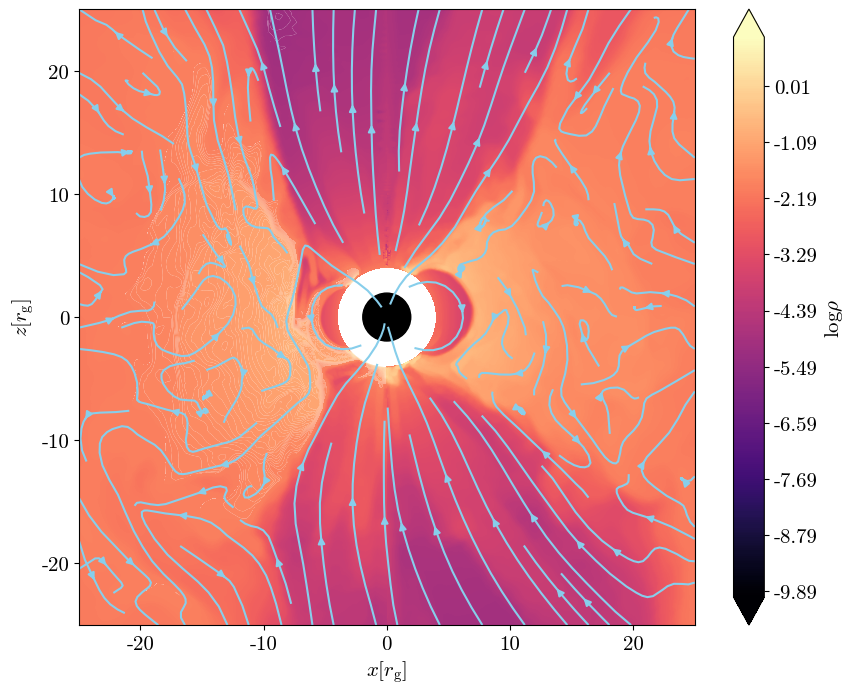

In [7]:
fig, ax, cs  = sim_init._contourf(np.log10(sim_init.rho), -10, 1,mode='phi',phi_offset=0,
                                  width=50,figsize=(10,8),
                                  stream={'type':'magnetic_field', 'linewidth':1.5,'color':'skyblue'},
                                  cmap='magma',fill_cells=1,dolog=0)

# fig = matplotlib figure, ax = matplotlib axis, cs = instead of matplotlib contourf plot
# you can use these to change labels/xticks/yticks
# i.e.
cbar = fig.colorbar(cs)
cbar.ax.set_ylabel(r'log$\rho$')
ax.set_xlabel(r'$x [r_{\rm g}]$')
ax.set_ylabel(r'$z [r_{\rm g}]$')

In [8]:
calc_drag_x = np.vectorize(sim_init._calc_drag_x)
calc_Pdot   = np.vectorize(sim_init._calc_Pdot)

cum_r = np.logspace(np.log10(sim_init.r[0,1,0,0]),np.log10(5*ra),100)
Fdrag = calc_drag_x(cum_r)/Pdot_ref

/tmp/ipykernel_233010/1996964077.py:1: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  plt.plot(cum_r/ra,Fdrag)


(0.04, 4.0)

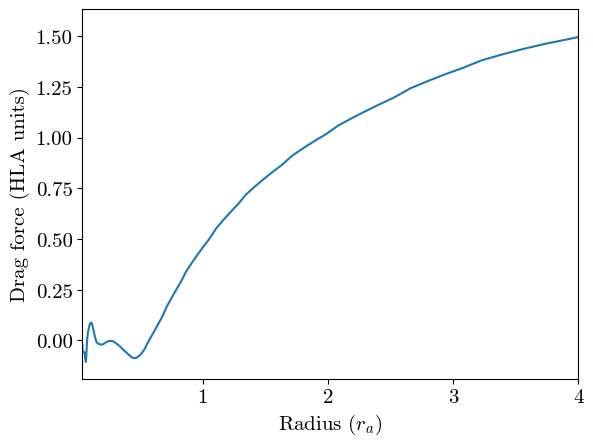

In [9]:
plt.plot(cum_r/ra,Fdrag)
plt.xlabel(r'Radius ($r_a$)')
plt.ylabel(r'Drag force (HLA units)')
plt.xlim(4/ra,4)

In [ ]:
calc_Pdot   = np.vectorize(sim_init._calc_Pdot)
Pdot  = calc_Pdot()

In [ ]:
def getting_quantities(D):
    sim_init = sim.Simulation(sim_dir,D, flatten=1, r_min=r_min,r_max=r_max,theta_min=theta_min,theta_max=theta_max,phi_min=phi_min,phi_max=phi_max)
    index_lc=max(np.where(sim_init.r[0,:,0,0]<r_lc)[0])

    lum_jet=sim_init.lum_jet_NS[0][index_lc]
    mag_flux=sim_init.mag_flux_NS[0][index_lc]
    torque=sim_init.torque_NS[0][0]
    mdot=sim_init.mdot[0][0]
    
    return(mdot, lum_jet, mag_flux,torque, sim_init.t)